In [ ]:

# Install required packages
!pip install torch numpy shap pandas -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import shap
import random
import pandas as pd
from datetime import datetime

# ==========================================
# REPRODUCIBILITY
# ==========================================
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ==========================================
# CONFIG
# ==========================================
device = "cpu"
HIDDEN_SIZE = 60
EPOCHS = 300
BATCH_SIZE = 32
LR = 0.001
MAX_N = 8

FEATURE_NAMES = ['X', 'Y', 'A', 'B', 'EOS']
symbol_to_idx = {'X': 0, 'Y': 1, 'A': 2, 'B': 3, 'EOS': 4}

# ==========================================
# DATA GENERATION
# ==========================================
def generate_sequence():
    valid = np.random.rand() > 0.5
    rule = np.random.choice(['X', 'Y'])
    n = np.random.randint(1, MAX_N + 1)

    seq = [rule] + ['A'] * n

    if rule == 'X':
        seq += ['B'] * (n if valid else n + np.random.choice([-1, 1]))
    else:
        seq += ['B'] * (2*n if valid else 2*n + np.random.choice([-1, 1]))

    seq.append('EOS')
    onehot = np.eye(5)[[symbol_to_idx[s] for s in seq]]
    return onehot, float(valid)

class GrammarDataset(Dataset):
    def __init__(self, n_samples=3000):  # 3000 samples like Phi* code
        self.data = [generate_sequence() for _ in range(n_samples)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y)

def collate(batch):
    xs, ys = zip(*batch)
    max_len = max(x.shape[0] for x in xs)
    padded = []
    for x in xs:
        pad = torch.zeros(max_len - x.shape[0], 5)
        padded.append(torch.cat([x, pad], 0))
    return torch.stack(padded), torch.tensor(ys)

# ==========================================
# GRU MODEL
# ==========================================
class GrammarGRU(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.gru = nn.GRU(5, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return torch.sigmoid(self.fc(h.squeeze(0))), h  # Sigmoid in forward, matching Phi* code

# ==========================================
# SHAP FUNCTION
# ==========================================
def compute_shap(model, dataset):
    model.eval()

    SEQ_LEN = max(dataset.data[i][0].shape[0] for i in range(len(dataset.data)))

    def to_flat(indices):
        items = []
        for i in indices:
            x, _ = dataset.data[i]
            pad_len = SEQ_LEN - x.shape[0]
            if pad_len > 0:
                x = np.concatenate([x, np.zeros((pad_len, 5))], 0)
            items.append(x.reshape(-1))
        return torch.tensor(np.stack(items), dtype=torch.float32)

    background = to_flat(range(0, 80))
    explain    = to_flat(range(80, 120))

    class Wrapper(nn.Module):
        def __init__(self, base_model):
            super().__init__()
            self.base_model = base_model

        def forward(self, x_flat):
            x = x_flat.view(-1, SEQ_LEN, 5)
            pred, _ = self.base_model(x)  # Model returns (pred, h)
            return pred

    wrapper = Wrapper(model)
    explainer = shap.GradientExplainer(wrapper, background)

    shap_vals = explainer.shap_values(explain)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[0]

    shap_vals = np.array(shap_vals)
    shap_3d = shap_vals.reshape(shap_vals.shape[0], SEQ_LEN, 5)
    shap_mean = np.mean(np.abs(shap_3d), axis=(0,1))

    return shap_mean

# ==========================================
# TRAIN FUNCTION
# ==========================================
def train_model_with_shap(model, train_loader, test_loader, full_dataset):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCELoss()  # BCELoss like Phi* code (not BCEWithLogitsLoss)

    results = []

    for epoch in range(EPOCHS):
        # Train
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            pred, _ = model(x)  # Model returns (pred, h)
            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()

        # Evaluate
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in test_loader:
                pred, _ = model(x)  # Model returns (pred, h)
                pred_binary = (pred.squeeze() > 0.5).float()
                correct += (pred_binary == y).sum().item()
                total += y.size(0)

        acc = correct / total

        # Compute SHAP
        print(f"Epoch {epoch+1}/{EPOCHS} | Computing SHAP...", end='\r')
        shap_mean = compute_shap(model, full_dataset)

        # Calculate total SHAP (sum of all features)
        total_shap = float(np.sum(shap_mean))

        # Store results
        epoch_result = {
            'epoch': epoch + 1,
            'accuracy': acc,
            'shap_X': float(shap_mean[0]),
            'shap_Y': float(shap_mean[1]),
            'shap_A': float(shap_mean[2]),
            'shap_B': float(shap_mean[3]),
            'shap_EOS': float(shap_mean[4]),
            'shap_total': total_shap
        }
        results.append(epoch_result)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Test Acc: {acc:.4f} | SHAP: X={shap_mean[0]:.4f}, Y={shap_mean[1]:.4f}, A={shap_mean[2]:.4f}, B={shap_mean[3]:.4f}, EOS={shap_mean[4]:.4f}, Total={total_shap:.4f}")

    return results

# ==========================================
# MAIN EXECUTION
# ==========================================
print("=" * 80)
print("Training GRU Model with SHAP Analysis")
print("=" * 80)
print()

# Create dataset (3000 samples like Phi* code)
full_dataset = GrammarDataset(n_samples=3000)

train_size = int(0.8 * len(full_dataset))
test_size  = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate)

test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate)

# Train model
model = GrammarGRU(HIDDEN_SIZE).to(device)
results = train_model_with_shap(model, train_loader, test_loader, full_dataset)

# Convert to DataFrame
df = pd.DataFrame(results)

# Reorder columns for better readability
df = df[['epoch', 'accuracy', 'shap_X', 'shap_Y', 'shap_A', 'shap_B', 'shap_EOS', 'shap_total']]

# Save to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f"gru_shap_results_{timestamp}.csv"
df.to_csv(csv_filename, index=False)

print()
print("=" * 80)
print(f"Training Complete!")
print("=" * 80)
print(f"Final Accuracy: {results[-1]['accuracy']:.4f}")
print(f"Final Total SHAP: {results[-1]['shap_total']:.4f}")
print(f"\nResults saved to: {csv_filename}")
print()
print("First 5 rows:")
print(df.head())
print()
print("Last 5 rows:")
print(df.tail())
print()
print("Summary Statistics:")
print(df.describe())

# Download the CSV file (for Colab)
from google.colab import files
files.download(csv_filename)
print(f"\n✓ CSV file downloaded: {csv_filename}")

Training GRU Model with SHAP Analysis

Epoch 10/300 | Test Acc: 0.4683 | SHAP: X=0.0000, Y=0.0000, A=0.0000, B=0.0002, EOS=0.0001, Total=0.0002
Epoch 20/300 | Test Acc: 0.5183 | SHAP: X=0.0000, Y=0.0000, A=0.0000, B=0.0005, EOS=0.0006, Total=0.0011
Epoch 30/300 | Test Acc: 0.5267 | SHAP: X=0.0000, Y=0.0000, A=0.0000, B=0.0001, EOS=0.0000, Total=0.0002
Epoch 40/300 | Test Acc: 0.4583 | SHAP: X=0.0000, Y=0.0000, A=0.0000, B=0.0002, EOS=0.0000, Total=0.0002
Epoch 50/300 | Test Acc: 0.4967 | SHAP: X=0.0000, Y=0.0000, A=0.0000, B=0.0001, EOS=0.0000, Total=0.0002
Epoch 60/300 | Test Acc: 0.5850 | SHAP: X=0.0012, Y=0.0006, A=0.0014, B=0.0025, EOS=0.0012, Total=0.0070
Epoch 70/300 | Test Acc: 0.5850 | SHAP: X=0.0009, Y=0.0005, A=0.0008, B=0.0021, EOS=0.0007, Total=0.0048
Epoch 80/300 | Test Acc: 0.6767 | SHAP: X=0.0016, Y=0.0009, A=0.0016, B=0.0048, EOS=0.0064, Total=0.0154
Epoch 90/300 | Test Acc: 0.5267 | SHAP: X=0.0002, Y=0.0001, A=0.0001, B=0.0003, EOS=0.0001, Total=0.0007
Epoch 100/300 | 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ CSV file downloaded: gru_shap_results_20260226_092929.csv


Pearson correlation: 0.1316, p-value: 2.2575e-02
Spearman correlation: 0.3784, p-value: 1.1961e-11


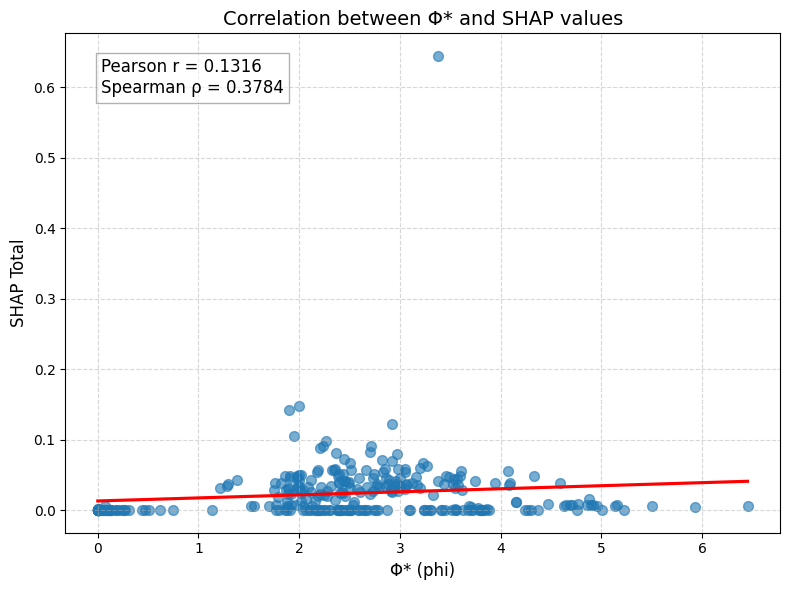

In [ ]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV files
phi_df = pd.read_csv('/content/gru_training_summary.csv')  # Columns: 'epoch', 'phi'
shap_df = pd.read_csv('/content/gru_shap_results_20260226_092929.csv')  # Columns: 'epoch', 'shap_total'

# Add epoch if missing
if 'epoch' not in phi_df.columns:
    phi_df['epoch'] = range(1, len(phi_df) + 1)
if 'epoch' not in shap_df.columns:
    shap_df['epoch'] = range(1, len(shap_df) + 1)

# Merge on epoch
merged_df = pd.merge(phi_df, shap_df, on='epoch')

# Compute correlations
pearson_corr, pearson_p = pearsonr(merged_df['phi'], merged_df['shap_total'])
spearman_corr, spearman_p = spearmanr(merged_df['phi'], merged_df['shap_total'])

print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4e}")
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")

# Plot
plt.figure(figsize=(8,6))
sns.regplot(x='phi', y='shap_total', data=merged_df, ci=None,
            scatter_kws={'s':50, 'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlation between Φ* and SHAP values', fontsize=14)
plt.xlabel('Φ* (phi)', fontsize=12)
plt.ylabel('SHAP Total', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate correlation coefficients
plt.text(0.05, 0.95, f"Pearson r = {pearson_corr:.4f}\nSpearman ρ = {spearman_corr:.4f}",
         transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.tight_layout()
plt.show()